In [62]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import numpy as np
import time
import os
from pynq import Overlay, allocate # PYNQ 라이브러리
import matplotlib.pyplot as plt   

print("PYNQ 환경에서 라이브러리 임포트 완료.")

try:
    print("PYNQ 오버레이 로드 시도...")
    overlay = Overlay('cnn.bit')
    conv_ip = overlay.Conv_IP_0
    dma_image = overlay.axi_dma_0
    dma_filter = overlay.axi_dma_1
    dma_output = overlay.axi_dma_2 
    print("오버레이 및 IP/DMA 성공적으로 로드됨.")
except Exception as e:
    print(f"오버레이 로드 실패: {e}")
    print("PYNQ 환경이 아니거나 .bit/.hwh 파일이 없습니다. 스크립트를 종료합니다.")
    exit()

# AXI-Lite 주소
ADDR_IMAGE_WIDTH    = 0x00
ADDR_INPUT_CHANNEL  = 0x04
ADDR_OUTPUT_CHANNEL = 0x08
ADDR_STRIDE         = 0x0C
ADDR_PADDING        = 0x10
ADDR_START          = 0x14
ADDR_EOC_STATUS     = 0x18

# 데이터 타입
DTYPE_IN = np.int8
DTYPE_IN_BIAS = np.int32 # 32비트 DMA로 W(int8)와 B(int32)를 함께 전송
DTYPE_OUT = np.int32 # 누적기(Accumulator) + Bias 결과

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

PYNQ 환경에서 라이브러리 임포트 완료.
PYNQ 오버레이 로드 시도...
오버레이 및 IP/DMA 성공적으로 로드됨.


In [63]:

device = torch.device('cpu')

class SimpleVGG(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleVGG, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),   # 0
            nn.ReLU(inplace=True),                       # 1
            nn.Conv2d(64, 64, kernel_size=3, padding=1),  # 2
            nn.ReLU(inplace=True),                       # 3
            nn.MaxPool2d(kernel_size=2, stride=2),      # 4
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # 5
            nn.ReLU(inplace=True),                       # 6
            nn.Conv2d(128, 128, kernel_size=3, padding=1),# 7
            nn.ReLU(inplace=True),                       # 8
            nn.MaxPool2d(kernel_size=2, stride=2),      # 9
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),# 10
            nn.ReLU(inplace=True),                       # 11
            nn.Conv2d(256, 256, kernel_size=3, padding=1),# 12
            nn.ReLU(inplace=True),                       # 13
            nn.MaxPool2d(kernel_size=2, stride=2),      # 14
        )
        self.classifier = nn.Sequential(
            nn.Linear(256 * 4 * 4, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, num_classes),
        )
    
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

print("SimpleVGG 모델 정의 완료.")

SimpleVGG 모델 정의 완료.


In [64]:

def quantize_symmetric_per_tensor(tensor, n_bits=8):
    scale = torch.max(torch.abs(tensor.detach())) / (2**(n_bits - 1) - 1) + 1e-8
    quantized_tensor = torch.round(tensor / scale).clamp(-128, 127).to(torch.int8)
    return quantized_tensor, scale

In [65]:

def plot_inference_result(image_tensor_cpu, pred_cpu_idx, pred_fpga_idx, true_label_idx, image_index):
    global classes # 전역 'classes' 리스트 사용
    
    try:
        # 1.
        mean = np.array([0.4914, 0.4822, 0.4465]).reshape(3, 1, 1)
        std = np.array([0.2023, 0.1994, 0.2010]).reshape(3, 1, 1)
        
        # 텐서를 numpy로 변환 (이미 CPU에 있어야 함)
        img_np = image_tensor_cpu.cpu().numpy()
        
        # (C, H, W) -> (H, W, C)
        img_unnormalized = (img_np * std + mean).transpose(1, 2, 0)
        
        # [0, 1] 범위로 클리핑
        img_clipped = np.clip(img_unnormalized, 0, 1)
        
        # 2. Plot
        plt.figure(figsize=(6, 6))
        plt.imshow(img_clipped)
        
        # 3. Title
        title_true = f"True: {classes[true_label_idx]}"
        
        if pred_cpu_idx is not None:
            title_cpu = f"CPU Pred: {classes[pred_cpu_idx]}"
            color_cpu = 'green' if pred_cpu_idx == true_label_idx else 'red'
            plt.figtext(0.5, 0.08, title_cpu, ha="center", fontsize=12, color=color_cpu)
        
        title_fpga = f"FPGA Pred: {classes[pred_fpga_idx]}"
        color_fpga = 'green' if pred_fpga_idx == true_label_idx else 'red'
        
        plt.title(f"Image #{image_index}\n{title_true}\n", fontsize=14)
        plt.figtext(0.5, 0.03, title_fpga, ha="center", fontsize=12, color=color_fpga)
        
        plt.axis('off')
        

    except Exception as e:
        print(f"  [플롯 경고] 이미지 #{image_index} 표시 실패: {e}")

In [66]:

def run_fpga_conv_layer(input_tensor_fp32, layer_index,
                        layer_params, prequantized_data,
                        image_buffer, filter_buffer, output_buffer):
    
    # 0. 레이어 파라미터 추출
    INPUT_CHANNEL = layer_params['ic']
    OUTPUT_CHANNEL = layer_params['oc']
    KERNEL_SIZE = layer_params['k']
    PADDING = layer_params['padding']
    STRIDE = layer_params['stride']
    IMAGE_WIDTH = input_tensor_fp32.shape[2] # Input [1, C, H, W]
    
    # 출력 이미지 크기 계산
    IMAGE_WIDTH_OUT = (IMAGE_WIDTH - KERNEL_SIZE + 2 * PADDING) // STRIDE + 1
    
    # 1. prequantized_data에서 미리 처리된 데이터 로드
    weight_data_padded_int32 = prequantized_data['weight_padded_int32']
    scale_w = prequantized_data['scale_w']
    bias_data_fp32 = prequantized_data['bias_fp32']
    
    input_one_image_fp32 = input_tensor_fp32[0] # [1,C,H,W] -> [C,H,W]

    # 2. 동적 양자화 (Input과 Bias)
    input_q, scale_in_torch = quantize_symmetric_per_tensor(input_one_image_fp32, n_bits=8)
    
    scale_in = scale_in_torch.item()
    
    scale_bias = scale_in * scale_w 
    bias_q = torch.round(bias_data_fp32 / scale_bias).to(torch.int32) # INT32 Bias

    # 3. FPGA 입력용 데이터 준비 (W/B Concat)
    
    # 3-A. Weight: 이미 준비됨
    
    # 3-B. Bias: 동적 양자화
    bias_data_flat_int32 = bias_q.cpu().numpy().flatten()
    
    # 3-C. Concat 
    filter_data_np = np.concatenate((weight_data_padded_int32, bias_data_flat_int32))
    
    # 3-D. Input
    image_data_np_3d = input_q.contiguous().cpu().numpy() # (C, H, W), INT8
    image_data_np = image_data_np_3d.flatten()
    
    # 4. PYNQ DMA 버퍼 할당
    # - 공용 버퍼 사용
    image_len = image_data_np.shape[0] # 1D
    filter_len = filter_data_np.shape[0] # 1D
    
    output_shape_fpga = (IMAGE_WIDTH_OUT, IMAGE_WIDTH_OUT, OUTPUT_CHANNEL) # FPGA 출력 규격: (H, W, N)
    output_total_elements = IMAGE_WIDTH_OUT * IMAGE_WIDTH_OUT * OUTPUT_CHANNEL # 1D
    
    if (image_buffer.shape[0] < image_len or 
        filter_buffer.shape[0] < filter_len or
        output_buffer.shape[0] < output_total_elements):
        print(f"치명적 오류: 레이어 #{layer_index}에서 공용 버퍼 크기 부족.")
        return None

    # 5. AXI-Lite 파라미터 설정
    conv_ip.write(ADDR_IMAGE_WIDTH, IMAGE_WIDTH)
    conv_ip.write(ADDR_INPUT_CHANNEL, INPUT_CHANNEL)
    conv_ip.write(ADDR_OUTPUT_CHANNEL, OUTPUT_CHANNEL)
    conv_ip.write(ADDR_STRIDE, STRIDE)
    conv_ip.write(ADDR_PADDING, PADDING)

    # 6. FPGA 실행
    image_buffer[0:image_len] = image_data_np
    filter_buffer[0:filter_len] = filter_data_np
    output_buffer.fill(0)
    
    image_buffer_view = image_buffer[0:image_len]
    filter_buffer_view = filter_buffer[0:filter_len]
    output_buffer_view = output_buffer[0:output_total_elements]
    
    dma_output.recvchannel.transfer(output_buffer_view)
    dma_filter.sendchannel.transfer(filter_buffer_view)
    dma_image.sendchannel.transfer(image_buffer_view)
    
    conv_ip.write(ADDR_START, 1) # 실행!

    while not (conv_ip.read(ADDR_EOC_STATUS) & 0x1):
        pass
    
    dma_filter.sendchannel.wait()
    dma_image.sendchannel.wait()
    dma_output.recvchannel.wait()

    # 7. 출력 처리 (역양자화 및 Transpose)
    output_fpga_int32_np = np.array(output_buffer_view).reshape(output_shape_fpga)
    output_fpga_int32 = torch.from_numpy(output_fpga_int32_np) # (H, W, N)
    
    output_fp32 = output_fpga_int32.float() * scale_bias
    output_pytorch_fp32 = output_fp32.permute(2, 0, 1) # (N, H, W)

    # 9. 배치 차원(1)을 다시 추가하여 리턴
    final_output_tensor = output_pytorch_fp32.unsqueeze(0).to(device) # [1, N, H, W]
    
    return final_output_tensor


In [67]:

def pynq_accelerated_inference(model, image_batch,
                               image_buffer_shared, 
                               filter_buffer_shared, 
                               output_buffer_shared,
                               layer_params_list,
                               prequantized_data_list):
    """
    모델의 'features' 모듈을 수동으로 실행하며
    Conv2d는 'run_fpga_conv_layer'로, 나머지는 CPU로 실행.
    """
    
    x = image_batch.to(device) # PYNQ의 CPU로 데이터 이동
    conv_layer_index = 0
    
    try:
        for i, layer in enumerate(model.features):
            
            if isinstance(layer, nn.Conv2d):
                layer_params = layer_params_list[conv_layer_index]
                prequantized_data = prequantized_data_list[conv_layer_index]
                
                x = run_fpga_conv_layer(x, conv_layer_index,
                                        layer_params, 
                                        prequantized_data,
                                        image_buffer_shared, 
                                        filter_buffer_shared, 
                                        output_buffer_shared)
                
                if x is None: # run_fpga_conv_layer에서 오류 발생 시
                    raise Exception(f"FPGA 레이어 {conv_layer_index} 실행 중 오류 발생")
                    
                conv_layer_index += 1
            else:
                # ReLU, MaxPool 등은 PyTorch(CPU)로 실행
                x = layer(x)
                
        # Classifier는 PyTorch(CPU)로 실행
        x = torch.flatten(x, 1)
        x = model.classifier(x)
        
    except Exception as e:
        print(f"추론 중단됨: {e}")
        x = None # 오류 발생 시 None 반환
        
    return x # 정상 결과 또는 None 반환


In [68]:

print("=" * 50)
print("     [ PYNQ 추론 및 검증 단계 시작 ]")
print("=" * 50)

# Colab에서 학습한 모델 로드
MODEL_PATH = 'simple_vgg_trained.pth'
inference_model = SimpleVGG(num_classes=10).to(device)

try:
    # map_location=device (cpu)로 강제
    inference_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print(f"성공: '{MODEL_PATH}'에서 학습된 가중치를 불러왔습니다.")
except Exception as e:
    print(f"가중치 로드 실패: {e}. (.pth 파일이 필요합니다)")
    # exit()

inference_model.eval() # 추론 모드 설정

# BATCH_SIZE=1로 고정
BATCH_SIZE_PYNQ = 1 
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
# BATCH_SIZE=1, shuffle=False로 1개씩 순서대로 테스트
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE_PYNQ, shuffle=False, num_workers=2)

print(f"테스트 데이터 로더 준비 완료 (배치 크기: {BATCH_SIZE_PYNQ})")


     [ PYNQ 추론 및 검증 단계 시작 ]
성공: 'simple_vgg_trained.pth'에서 학습된 가중치를 불러왔습니다.
Files already downloaded and verified
테스트 데이터 로더 준비 완료 (배치 크기: 1)


In [69]:

print("\n[추론 준비] Weight/Bias 사전 처리 및 양자화 시작...")
layer_params_list = []      # FPGA IP 설정값 (IC, OC, Stride...)
prequantized_data_list = [] # 미리 처리된 W/B 텐서

try:
    with torch.no_grad(): # 사전 처리 중에는 그래디언트 필요 없음
        for layer in inference_model.features:
            if isinstance(layer, nn.Conv2d):
                # 1. 레이어 파라미터 추출
                OC, IC, K, _ = layer.weight.shape
                params = {
                    'oc': OC,
                    'ic': IC,
                    'k': K,
                    'padding': layer.padding[0],
                    'stride': layer.stride[0]
                }
                layer_params_list.append(params)
                
                # 2. Weight/Bias 텐서 추출
                weight_data_fp32 = layer.weight.data.cpu()
                bias_data_fp32 = layer.bias.data.cpu()
                
                # 3. Weight만 미리 양자화, 재배열, 패딩
                weight_q, scale_w_torch = quantize_symmetric_per_tensor(weight_data_fp32, n_bits=8)
                weight_q_transposed = weight_q.permute(1, 0, 2, 3) # (IC, OC, K, K)
                weight_q_flat_int8 = weight_q_transposed.cpu().numpy().flatten()
                weight_data_padded_int32 = weight_q_flat_int8.astype(np.int32)
                
                # 4. 리스트에 저장
                data_dict = {
                    'weight_padded_int32': weight_data_padded_int32, # 미리 패딩된 INT32 Weight
                    'scale_w': scale_w_torch.item(),                 # Weight 스케일
                    'bias_fp32': bias_data_fp32                      # 원본 FP32 Bias
                }
                prequantized_data_list.append(data_dict)

    print(f"사전 처리 완료. 총 {len(prequantized_data_list)}개의 Conv 레이어 데이터 준비됨.")
except Exception as e:
    print(f"치명적 오류: Weight/Bias 사전 처리 실패: {e}")
    # exit()



[추론 준비] Weight/Bias 사전 처리 및 양자화 시작...
사전 처리 완료. 총 6개의 Conv 레이어 데이터 준비됨.



[추론 준비] 공용 DMA 버퍼 할당 시도...
공용 DMA 버퍼 3개 할당 성공.

테스트셋 *1000*개 이미지에 대한 정확도 비교 시작...
[이미지 #0] Time (CPU):  3405.02 ms | Time (FPGA):   275.65 ms
[이미지 #1] Time (CPU):  3315.34 ms | Time (FPGA):   262.28 ms
[이미지 #2] Time (CPU):  3316.26 ms | Time (FPGA):   263.57 ms
[이미지 #3] Time (CPU):  3321.39 ms | Time (FPGA):   262.26 ms
[이미지 #4] Time (CPU):  3316.81 ms | Time (FPGA):   263.62 ms
[이미지 #5] Time (CPU):  3315.09 ms | Time (FPGA):   261.96 ms
[이미지 #6] Time (CPU):  3314.53 ms | Time (FPGA):   263.94 ms
[이미지 #7] Time (CPU):  3319.49 ms | Time (FPGA):   262.32 ms
[이미지 #8] Time (CPU):  3319.39 ms | Time (FPGA):   263.57 ms
[이미지 #9] Time (CPU):  3315.28 ms | Time (FPGA):   262.13 ms
[이미지 #10] Time (CPU):  3315.51 ms | Time (FPGA):   262.27 ms
[이미지 #11] Time (CPU):  3314.16 ms | Time (FPGA):   263.38 ms
[이미지 #12] Time (CPU):  3311.16 ms | Time (FPGA):   262.30 ms
[이미지 #13] Time (CPU):  3316.98 ms | Time (FPGA):   263.14 ms
[이미지 #14] Time (CPU):  3312.28 ms | Time (FPGA):   261.65 ms
[이미지 #15] Ti

[이미지 #133] Time (CPU):  3320.49 ms | Time (FPGA):   260.77 ms
[이미지 #134] Time (CPU):  3312.38 ms | Time (FPGA):   263.76 ms
[이미지 #135] Time (CPU):  3309.49 ms | Time (FPGA):   259.53 ms
[이미지 #136] Time (CPU):  3310.01 ms | Time (FPGA):   260.02 ms
[이미지 #137] Time (CPU):  3308.73 ms | Time (FPGA):   259.99 ms
[이미지 #138] Time (CPU):  3309.94 ms | Time (FPGA):   259.67 ms
[이미지 #139] Time (CPU):  3309.07 ms | Time (FPGA):   259.73 ms
[이미지 #140] Time (CPU):  3308.28 ms | Time (FPGA):   260.09 ms
[이미지 #141] Time (CPU):  3308.63 ms | Time (FPGA):   261.84 ms
[이미지 #142] Time (CPU):  3319.60 ms | Time (FPGA):   262.13 ms
[이미지 #143] Time (CPU):  3312.93 ms | Time (FPGA):   265.86 ms
[이미지 #144] Time (CPU):  3310.64 ms | Time (FPGA):   262.63 ms
[이미지 #145] Time (CPU):  3315.80 ms | Time (FPGA):   262.01 ms
[이미지 #146] Time (CPU):  3317.97 ms | Time (FPGA):   264.09 ms
[이미지 #147] Time (CPU):  3312.63 ms | Time (FPGA):   261.95 ms
[이미지 #148] Time (CPU):  3312.38 ms | Time (FPGA):   261.59 ms
[이미지 #14

<ipython-input-65-eb1fda1695f2>:25: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure(figsize=(6, 6))


[이미지 #201] Time (CPU):  3309.44 ms | Time (FPGA):   264.19 ms
[이미지 #202] Time (CPU):  3310.29 ms | Time (FPGA):   261.71 ms
[이미지 #203] Time (CPU):  3307.63 ms | Time (FPGA):   261.55 ms
[이미지 #204] Time (CPU):  3311.92 ms | Time (FPGA):   265.20 ms
[이미지 #205] Time (CPU):  3314.74 ms | Time (FPGA):   261.14 ms
[이미지 #206] Time (CPU):  3310.77 ms | Time (FPGA):   262.60 ms
[이미지 #207] Time (CPU):  3306.45 ms | Time (FPGA):   260.99 ms
[이미지 #208] Time (CPU):  3314.16 ms | Time (FPGA):   261.75 ms
[이미지 #209] Time (CPU):  3313.69 ms | Time (FPGA):   261.10 ms
[이미지 #210] Time (CPU):  3310.78 ms | Time (FPGA):   261.36 ms
[이미지 #211] Time (CPU):  3309.08 ms | Time (FPGA):   259.38 ms
[이미지 #212] Time (CPU):  3308.26 ms | Time (FPGA):   257.56 ms
[이미지 #213] Time (CPU):  3305.03 ms | Time (FPGA):   257.60 ms
[이미지 #214] Time (CPU):  3307.97 ms | Time (FPGA):   257.68 ms
[이미지 #215] Time (CPU):  3304.98 ms | Time (FPGA):   257.57 ms
[이미지 #216] Time (CPU):  3306.87 ms | Time (FPGA):   260.09 ms
[이미지 #21

[이미지 #334] Time (CPU):  3319.06 ms | Time (FPGA):   258.30 ms
[이미지 #335] Time (CPU):  3318.55 ms | Time (FPGA):   259.19 ms
[이미지 #336] Time (CPU):  3313.87 ms | Time (FPGA):   259.13 ms
[이미지 #337] Time (CPU):  3313.96 ms | Time (FPGA):   258.17 ms
[이미지 #338] Time (CPU):  3312.97 ms | Time (FPGA):   258.06 ms
[이미지 #339] Time (CPU):  3312.32 ms | Time (FPGA):   258.35 ms
[이미지 #340] Time (CPU):  3313.24 ms | Time (FPGA):   258.25 ms
[이미지 #341] Time (CPU):  3309.67 ms | Time (FPGA):   260.04 ms
[이미지 #342] Time (CPU):  3311.31 ms | Time (FPGA):   259.31 ms
[이미지 #343] Time (CPU):  3315.77 ms | Time (FPGA):   260.01 ms
[이미지 #344] Time (CPU):  3310.58 ms | Time (FPGA):   259.72 ms
[이미지 #345] Time (CPU):  3310.21 ms | Time (FPGA):   258.69 ms
[이미지 #346] Time (CPU):  3314.55 ms | Time (FPGA):   260.57 ms
[이미지 #347] Time (CPU):  3307.77 ms | Time (FPGA):   258.25 ms
[이미지 #348] Time (CPU):  3311.93 ms | Time (FPGA):   260.39 ms
[이미지 #349] Time (CPU):  3312.88 ms | Time (FPGA):   259.20 ms
[이미지 #35

[이미지 #467] Time (CPU):  3314.49 ms | Time (FPGA):   258.81 ms
[이미지 #468] Time (CPU):  3315.36 ms | Time (FPGA):   258.20 ms
[이미지 #469] Time (CPU):  3318.06 ms | Time (FPGA):   258.31 ms
[이미지 #470] Time (CPU):  3316.39 ms | Time (FPGA):   258.17 ms
[이미지 #471] Time (CPU):  3317.48 ms | Time (FPGA):   258.46 ms
[이미지 #472] Time (CPU):  3315.16 ms | Time (FPGA):   261.21 ms
[이미지 #473] Time (CPU):  3314.52 ms | Time (FPGA):   261.36 ms
[이미지 #474] Time (CPU):  3318.85 ms | Time (FPGA):   258.65 ms
[이미지 #475] Time (CPU):  3317.84 ms | Time (FPGA):   259.90 ms
[이미지 #476] Time (CPU):  3319.97 ms | Time (FPGA):   258.30 ms
[이미지 #477] Time (CPU):  3314.65 ms | Time (FPGA):   258.06 ms
[이미지 #478] Time (CPU):  3320.41 ms | Time (FPGA):   262.00 ms
[이미지 #479] Time (CPU):  3317.51 ms | Time (FPGA):   258.72 ms
[이미지 #480] Time (CPU):  3315.46 ms | Time (FPGA):   258.53 ms
[이미지 #481] Time (CPU):  3316.67 ms | Time (FPGA):   262.03 ms
[이미지 #482] Time (CPU):  3318.76 ms | Time (FPGA):   262.25 ms
[이미지 #48

[이미지 #600] Time (CPU):  3313.51 ms | Time (FPGA):   260.66 ms
[이미지 #601] Time (CPU):  3313.08 ms | Time (FPGA):   261.54 ms
[이미지 #602] Time (CPU):  3312.11 ms | Time (FPGA):   260.06 ms
[이미지 #603] Time (CPU):  3311.79 ms | Time (FPGA):   260.83 ms
[이미지 #604] Time (CPU):  3311.86 ms | Time (FPGA):   262.22 ms
[이미지 #605] Time (CPU):  3316.78 ms | Time (FPGA):   262.64 ms
[이미지 #606] Time (CPU):  3308.83 ms | Time (FPGA):   258.85 ms
[이미지 #607] Time (CPU):  3312.39 ms | Time (FPGA):   258.38 ms
[이미지 #608] Time (CPU):  3312.09 ms | Time (FPGA):   259.08 ms
[이미지 #609] Time (CPU):  3314.13 ms | Time (FPGA):   259.62 ms
[이미지 #610] Time (CPU):  3314.18 ms | Time (FPGA):   260.46 ms
[이미지 #611] Time (CPU):  3309.30 ms | Time (FPGA):   263.94 ms
[이미지 #612] Time (CPU):  3319.60 ms | Time (FPGA):   266.00 ms
[이미지 #613] Time (CPU):  3313.14 ms | Time (FPGA):   265.51 ms
[이미지 #614] Time (CPU):  3314.55 ms | Time (FPGA):   265.33 ms
[이미지 #615] Time (CPU):  3312.47 ms | Time (FPGA):   266.19 ms
[이미지 #61

[이미지 #733] Time (CPU):  3314.94 ms | Time (FPGA):   259.60 ms
[이미지 #734] Time (CPU):  3316.91 ms | Time (FPGA):   259.51 ms
[이미지 #735] Time (CPU):  3315.56 ms | Time (FPGA):   258.18 ms
[이미지 #736] Time (CPU):  3320.26 ms | Time (FPGA):   258.31 ms
[이미지 #737] Time (CPU):  3313.58 ms | Time (FPGA):   257.64 ms
[이미지 #738] Time (CPU):  3321.36 ms | Time (FPGA):   257.96 ms
[이미지 #739] Time (CPU):  3315.33 ms | Time (FPGA):   258.01 ms
[이미지 #740] Time (CPU):  3319.23 ms | Time (FPGA):   258.15 ms
[이미지 #741] Time (CPU):  3313.82 ms | Time (FPGA):   259.70 ms
[이미지 #742] Time (CPU):  3313.76 ms | Time (FPGA):   258.03 ms
[이미지 #743] Time (CPU):  3316.09 ms | Time (FPGA):   258.46 ms
[이미지 #744] Time (CPU):  3315.10 ms | Time (FPGA):   259.05 ms
[이미지 #745] Time (CPU):  3316.70 ms | Time (FPGA):   259.43 ms
[이미지 #746] Time (CPU):  3316.25 ms | Time (FPGA):   259.28 ms
[이미지 #747] Time (CPU):  3315.63 ms | Time (FPGA):   258.28 ms
[이미지 #748] Time (CPU):  3315.75 ms | Time (FPGA):   258.07 ms
[이미지 #74

[이미지 #866] Time (CPU):  3312.15 ms | Time (FPGA):   259.59 ms
[이미지 #867] Time (CPU):  3313.66 ms | Time (FPGA):   259.42 ms
[이미지 #868] Time (CPU):  3309.56 ms | Time (FPGA):   259.40 ms
[이미지 #869] Time (CPU):  3310.85 ms | Time (FPGA):   259.31 ms
[이미지 #870] Time (CPU):  3309.53 ms | Time (FPGA):   259.60 ms
[이미지 #871] Time (CPU):  3312.80 ms | Time (FPGA):   258.92 ms
[이미지 #872] Time (CPU):  3315.59 ms | Time (FPGA):   259.90 ms
[이미지 #873] Time (CPU):  3311.81 ms | Time (FPGA):   259.98 ms
[이미지 #874] Time (CPU):  3311.24 ms | Time (FPGA):   259.65 ms
[이미지 #875] Time (CPU):  3308.11 ms | Time (FPGA):   259.67 ms
[이미지 #876] Time (CPU):  3312.98 ms | Time (FPGA):   259.52 ms
[이미지 #877] Time (CPU):  3307.59 ms | Time (FPGA):   259.42 ms
[이미지 #878] Time (CPU):  3310.38 ms | Time (FPGA):   260.53 ms
[이미지 #879] Time (CPU):  3308.95 ms | Time (FPGA):   259.55 ms
[이미지 #880] Time (CPU):  3309.71 ms | Time (FPGA):   260.52 ms
[이미지 #881] Time (CPU):  3314.79 ms | Time (FPGA):   258.34 ms
[이미지 #88

[이미지 #999] Time (CPU):  3312.85 ms | Time (FPGA):   261.31 ms
1000개 이미지 테스트 완료. 루프 종료.

공용 DMA 버퍼 해제 중...
공용 DMA 버퍼 모두 해제됨.

     *PYNQ 테스트* 최종 정확도 비교 결과 (1000개 샘플)
  - [A] PyTorch CPU 추론 정확도: 	80.70 % (807/1000)
  - [B] PYNQ FPGA 가속 추론 정확도: 	80.60 % (806/1000)
--------------------------------------------------
  - 정확도 차이 (A - B): +0.10 %

     *PYNQ 테스트* 최종 성능 비교 결과 (1000개 샘플)
  - [A] CPU 평균 추론 시간: 	3314.74 ms/image
  - [B] FPGA 평균 추론 시간: 	260.89 ms/image
--------------------------------------------------
  - FPGA 가속 성능: 12.71x (CPU 대비)

PYNQ 추론 스크립트 종료.


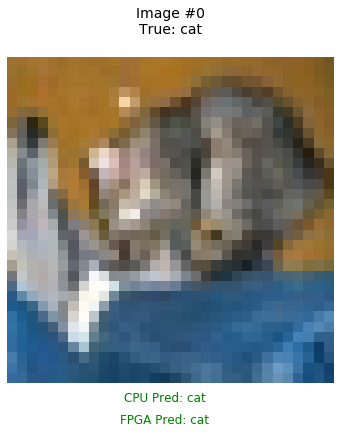

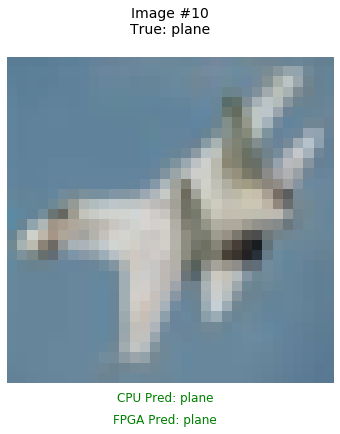

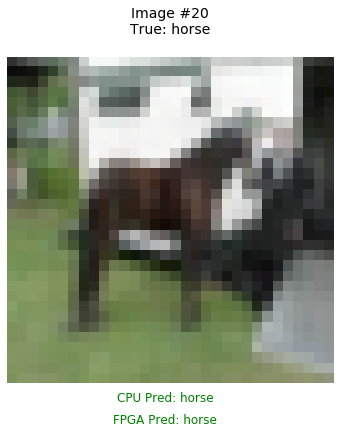

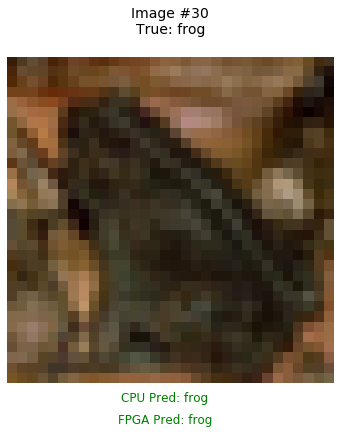

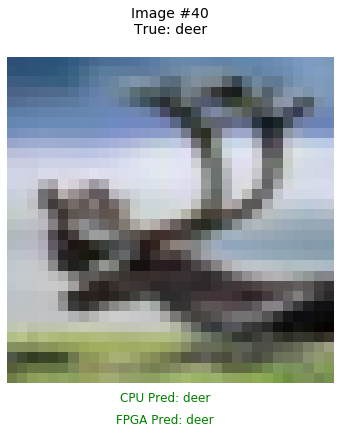

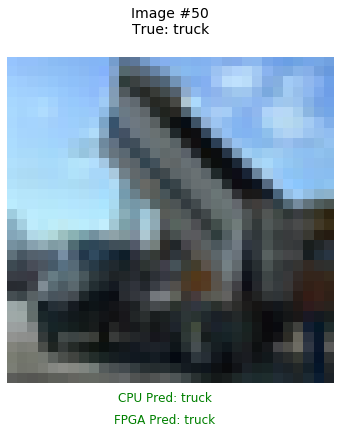

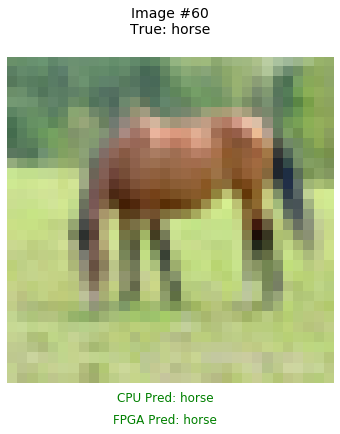

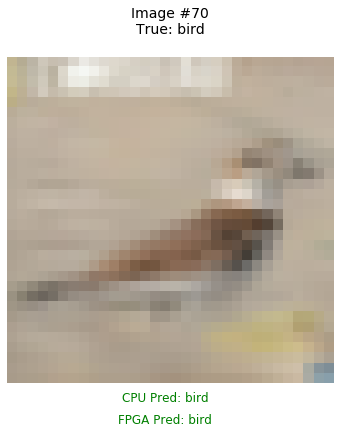

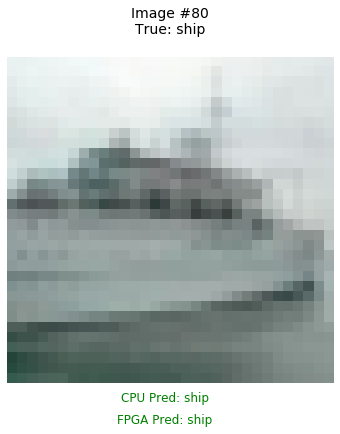

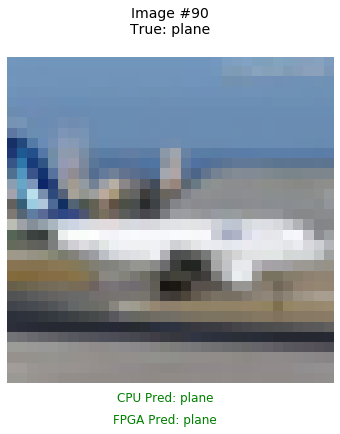

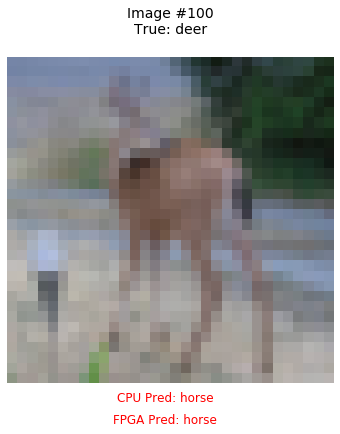

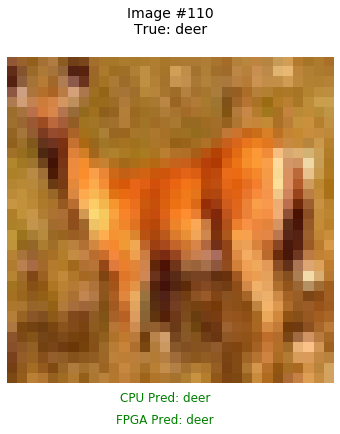

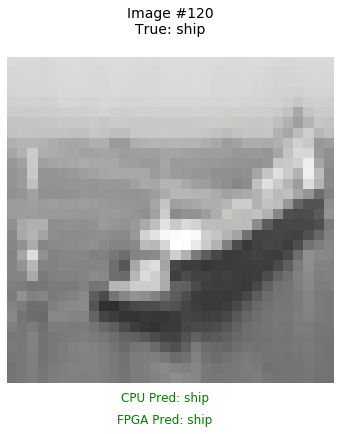

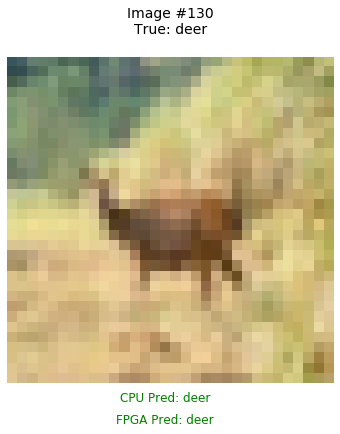

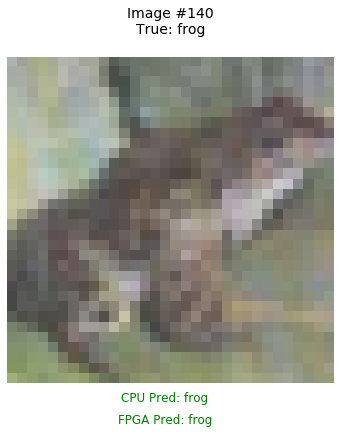

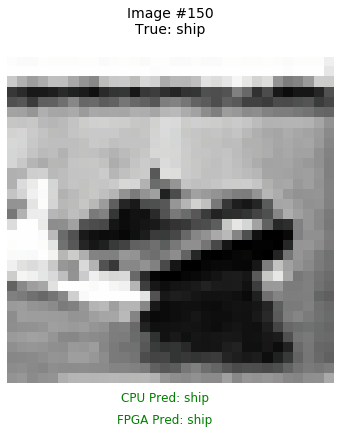

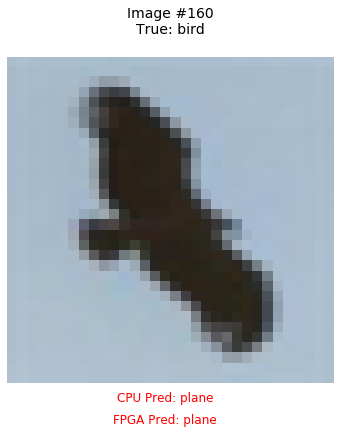

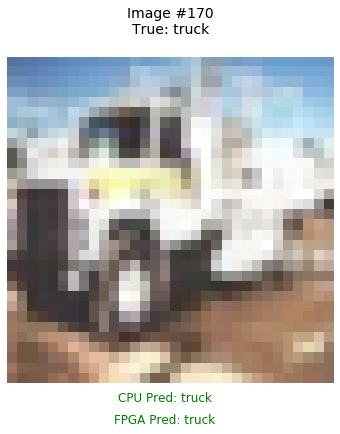

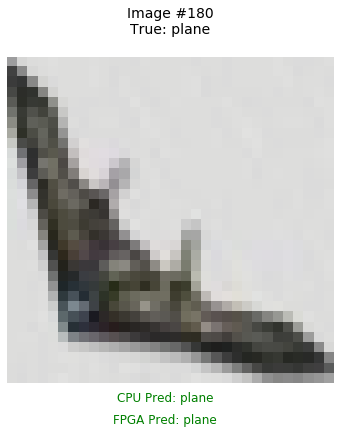

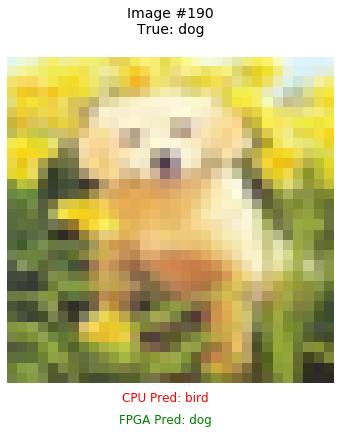

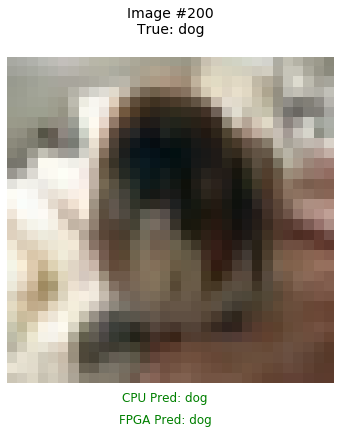

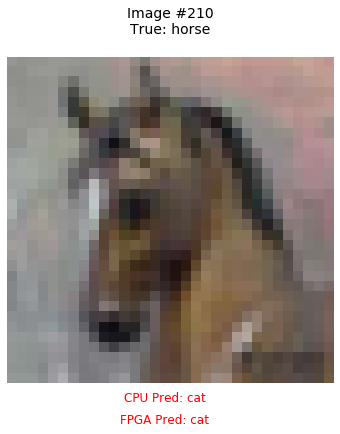

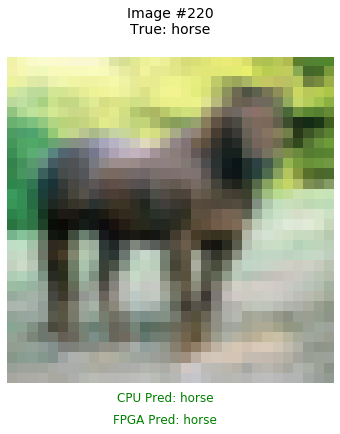

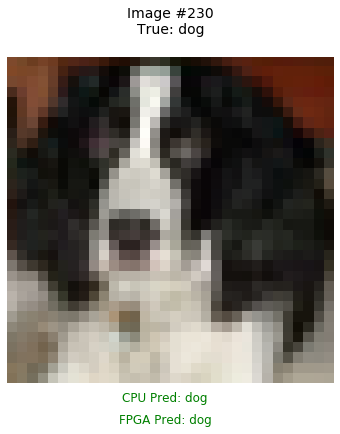

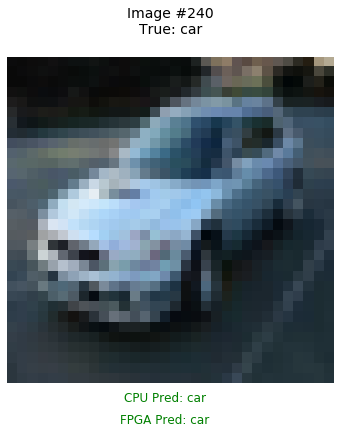

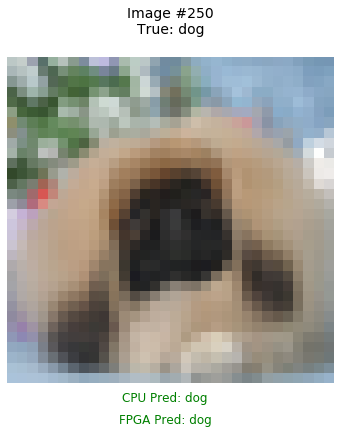

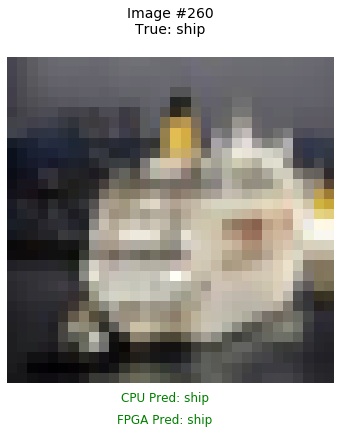

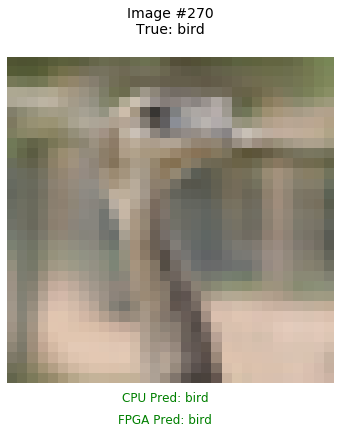

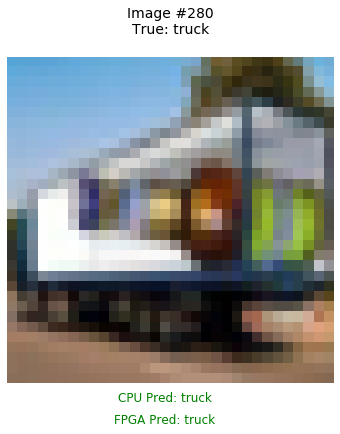

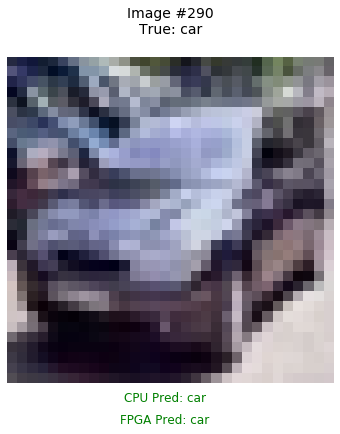

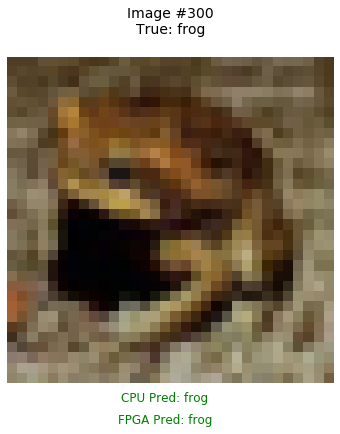

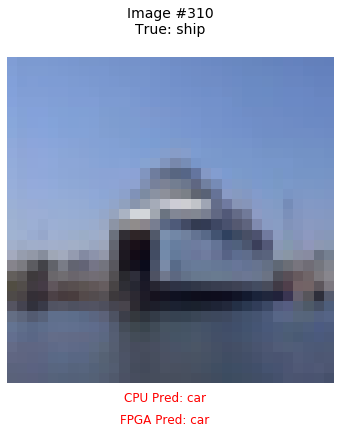

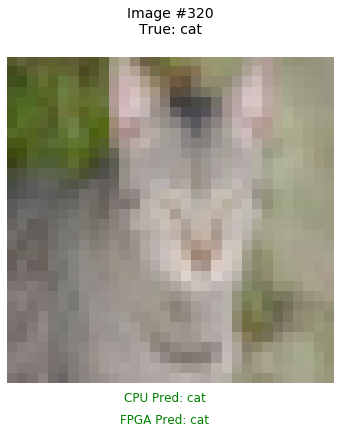

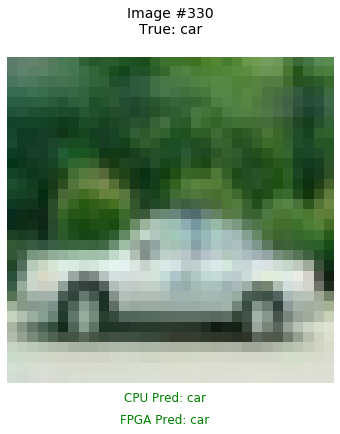

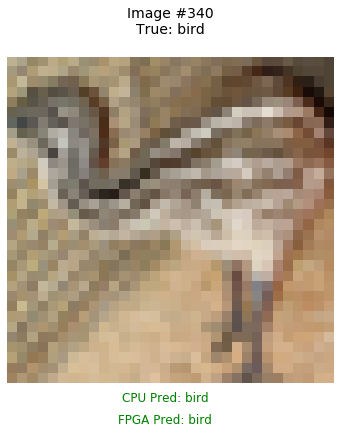

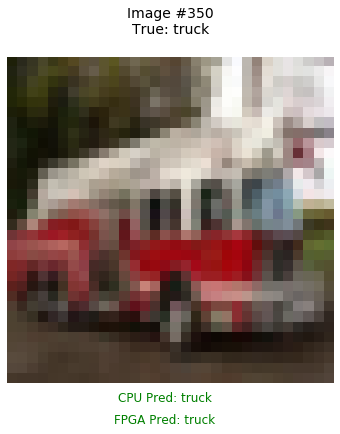

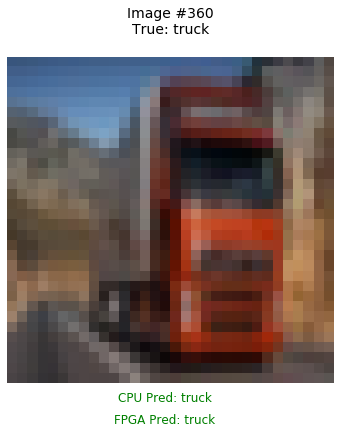

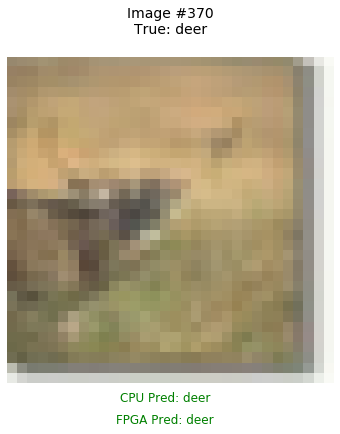

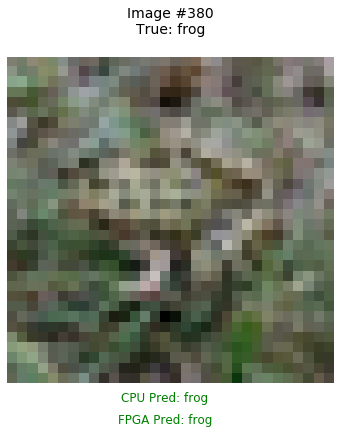

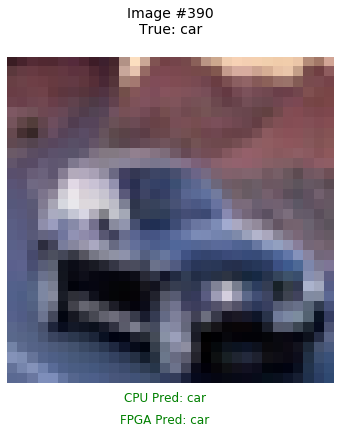

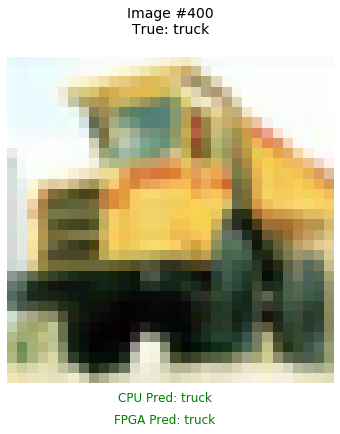

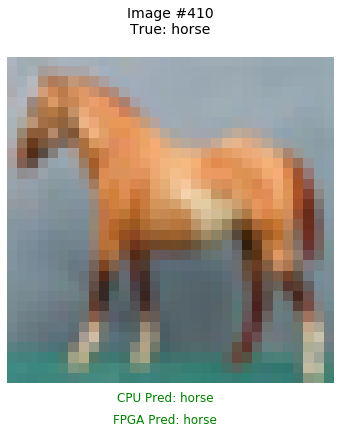

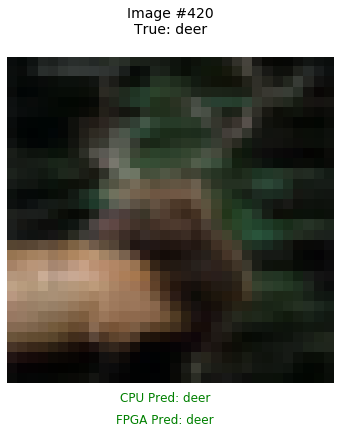

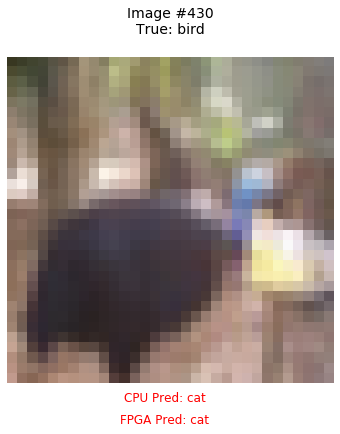

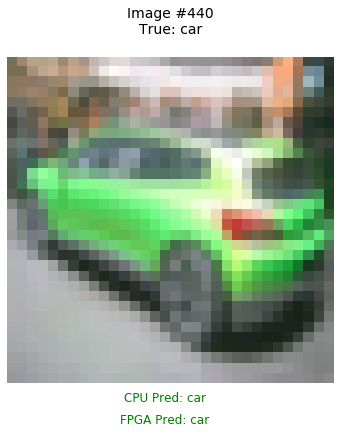

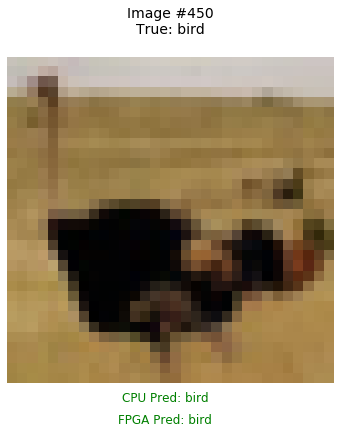

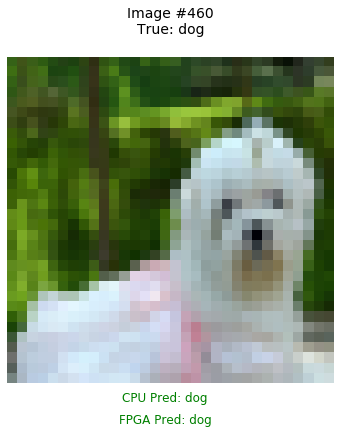

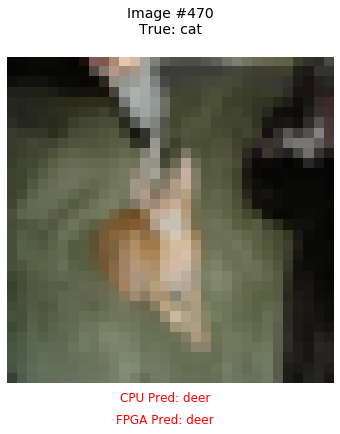

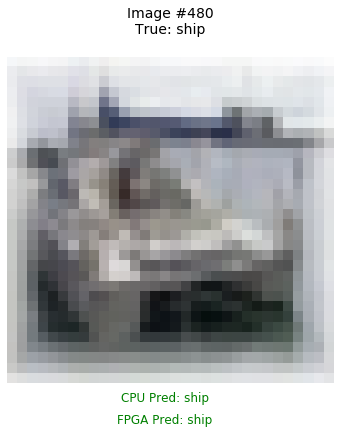

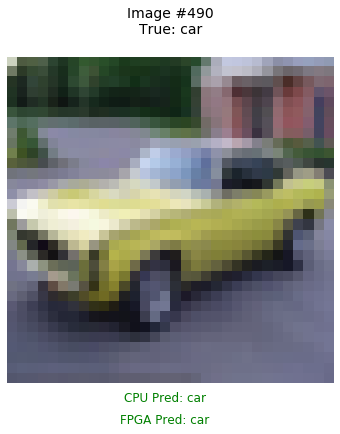

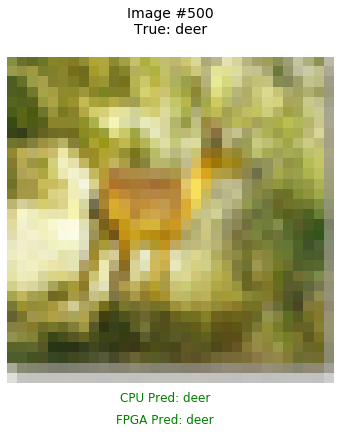

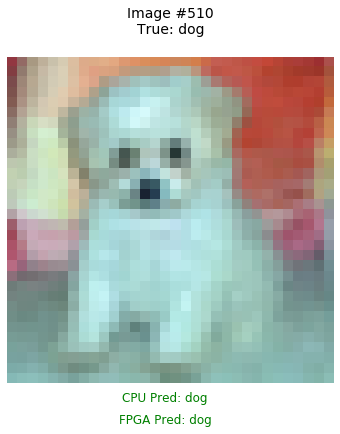

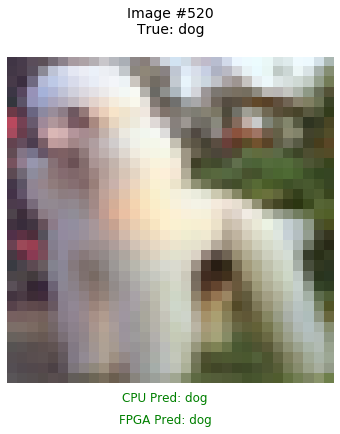

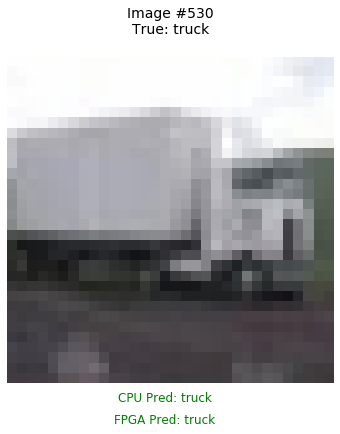

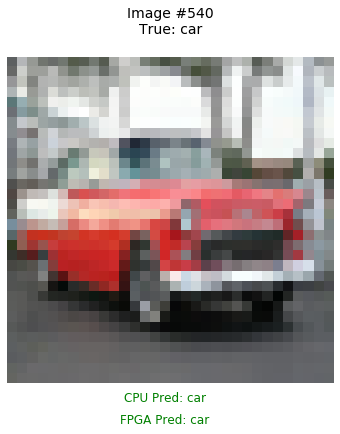

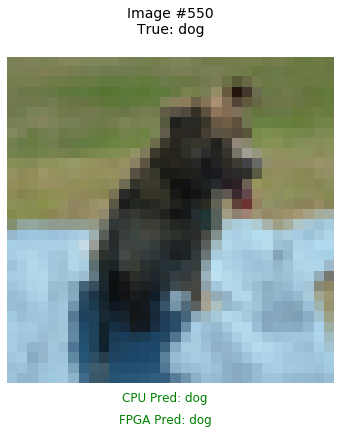

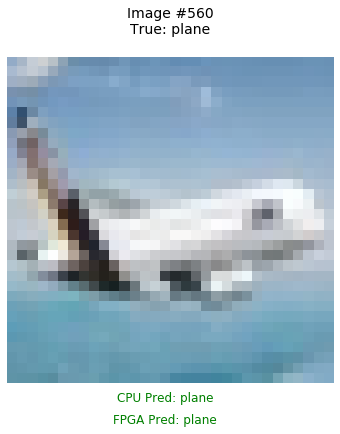

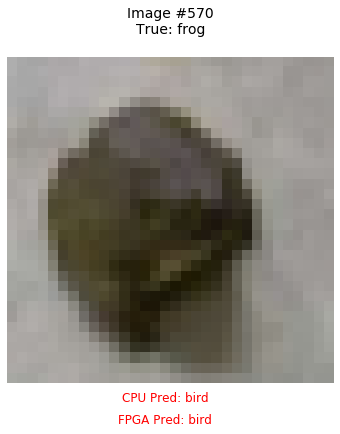

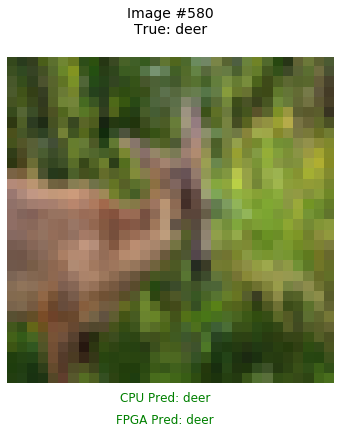

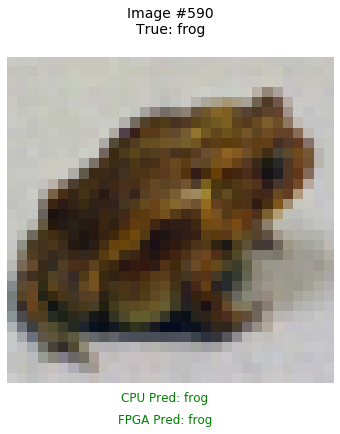

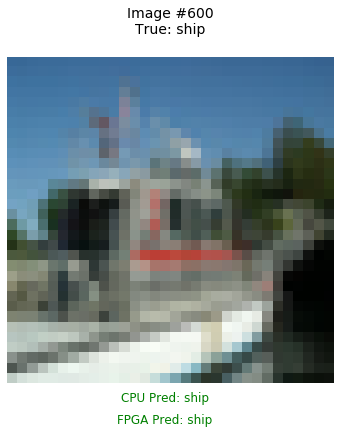

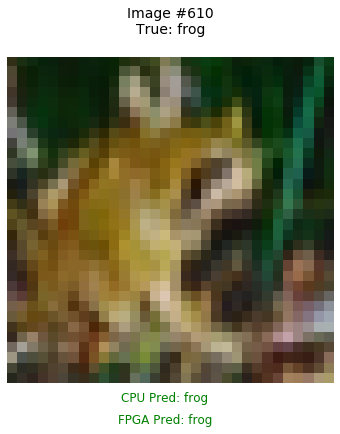

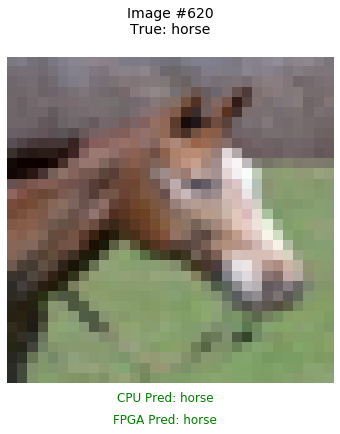

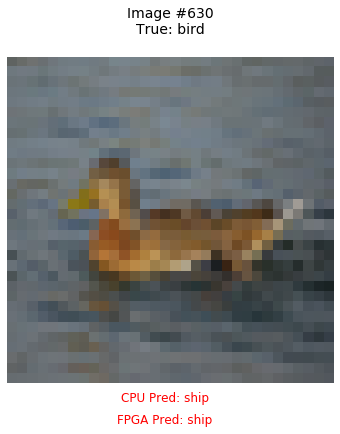

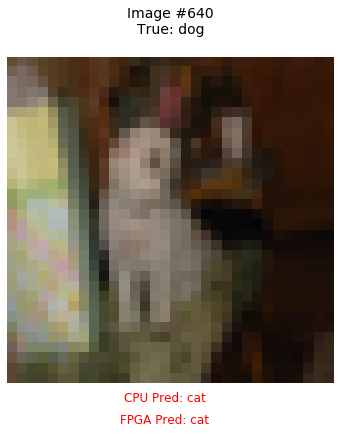

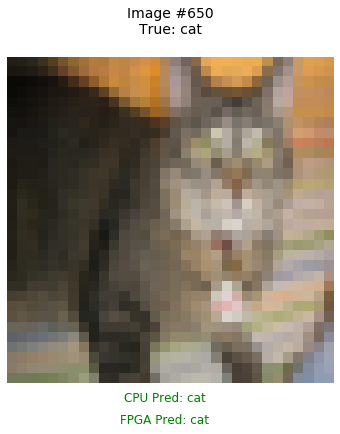

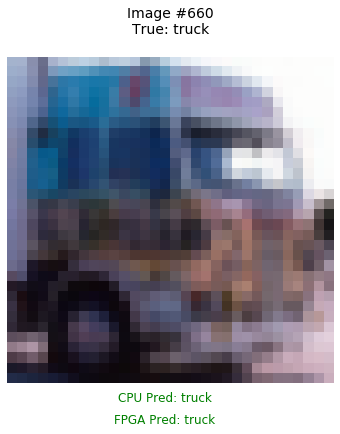

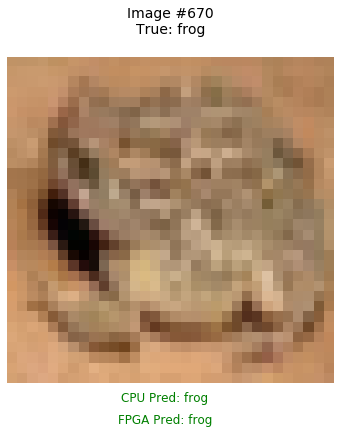

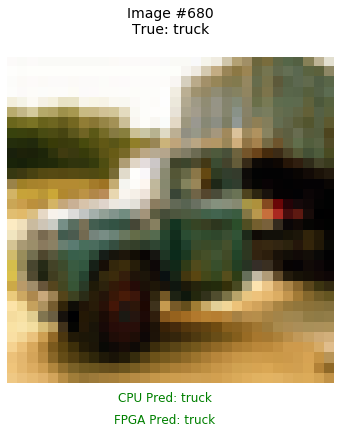

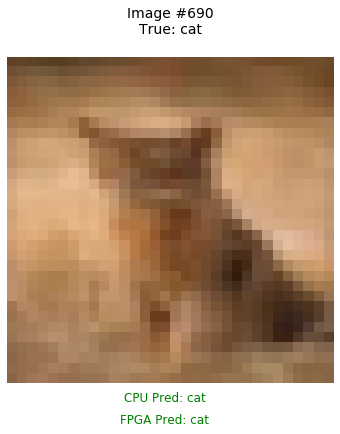

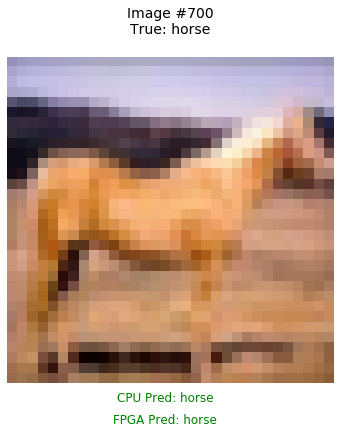

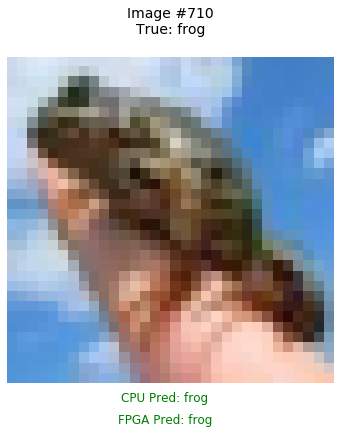

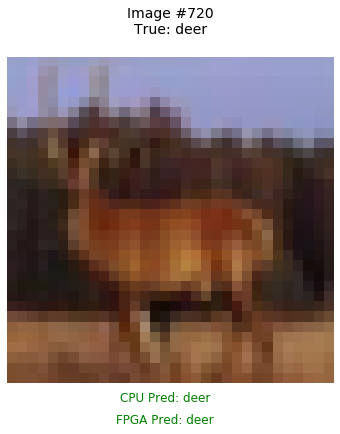

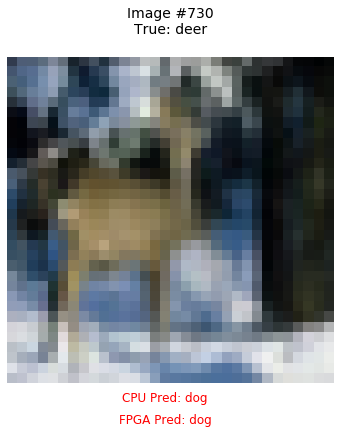

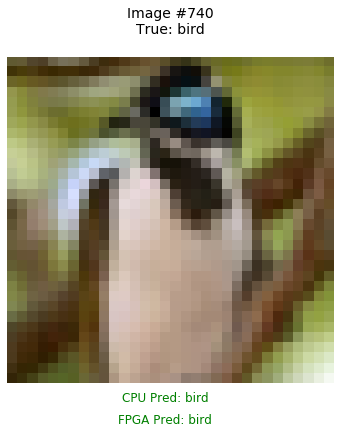

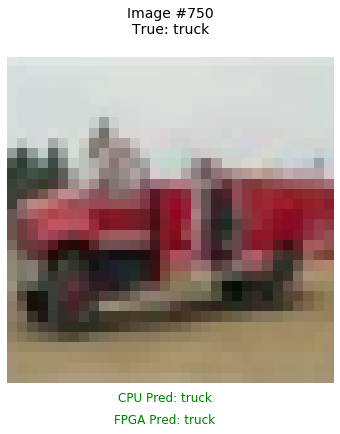

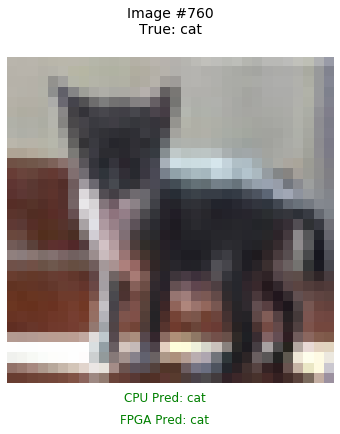

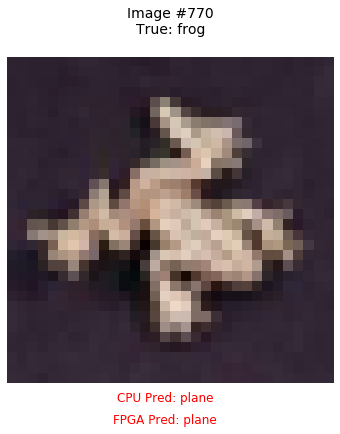

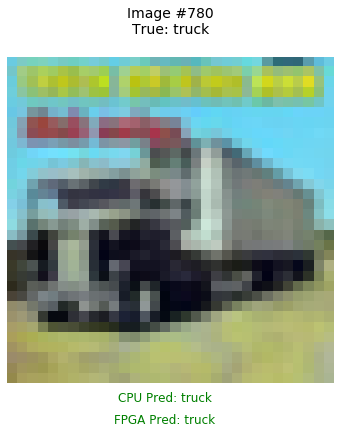

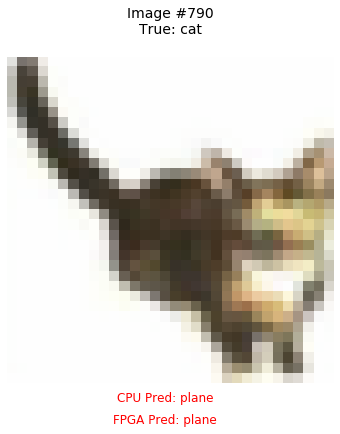

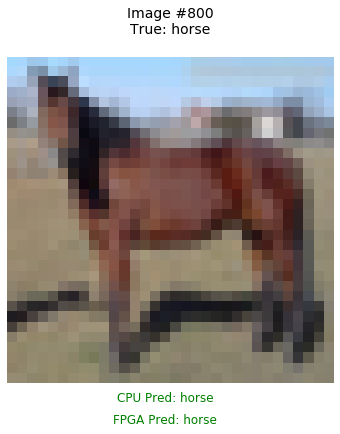

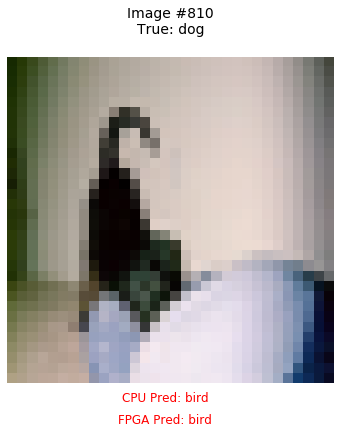

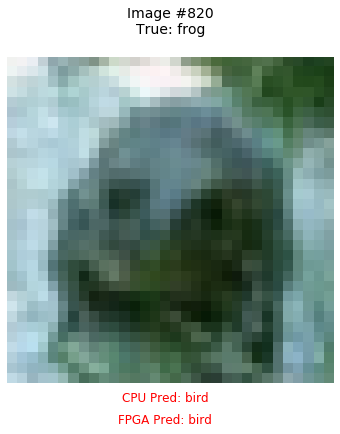

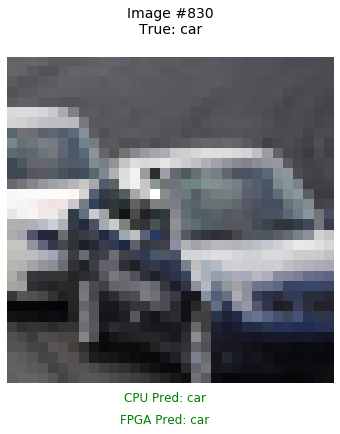

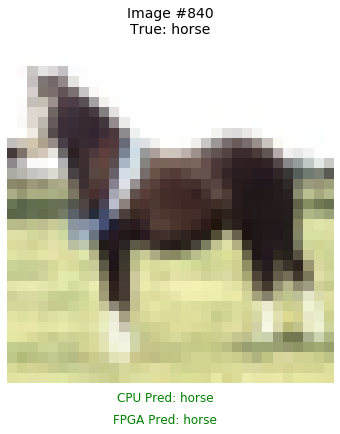

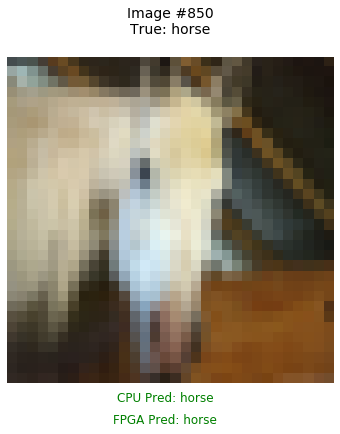

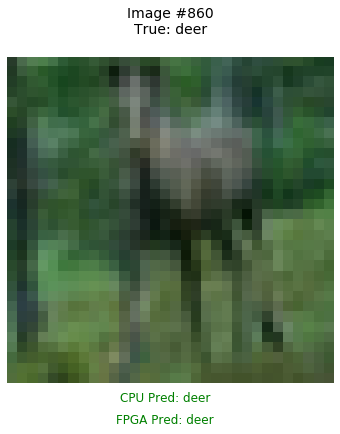

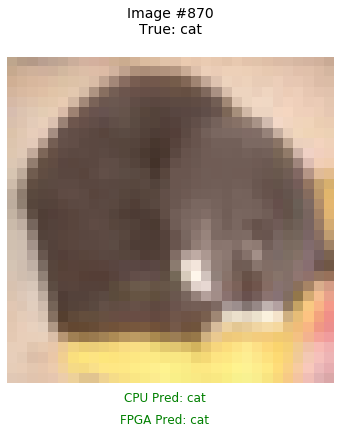

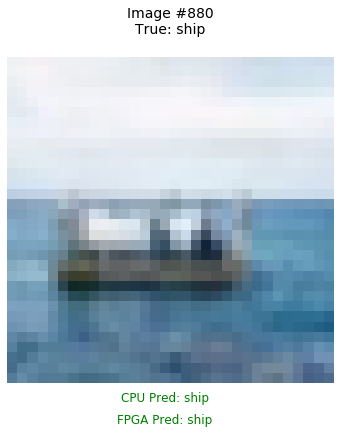

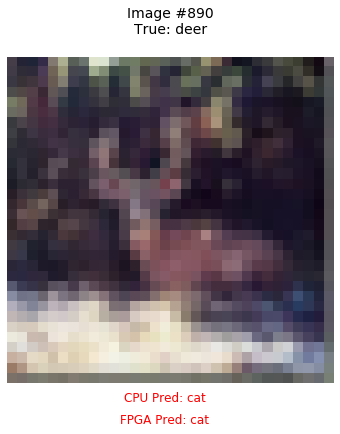

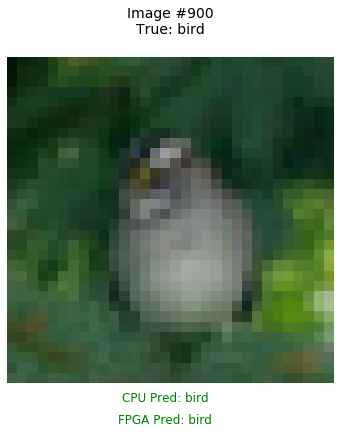

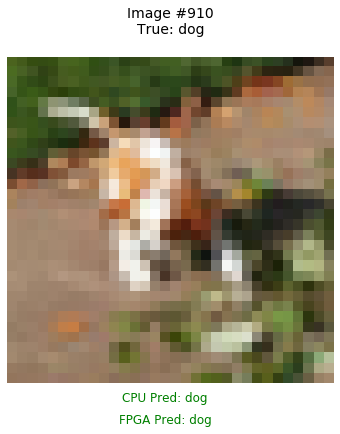

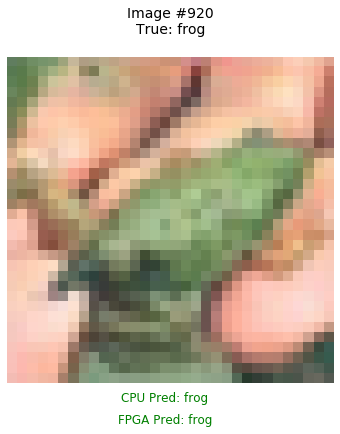

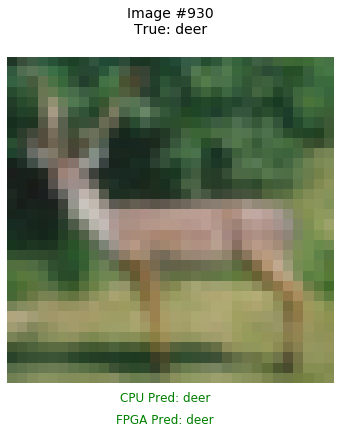

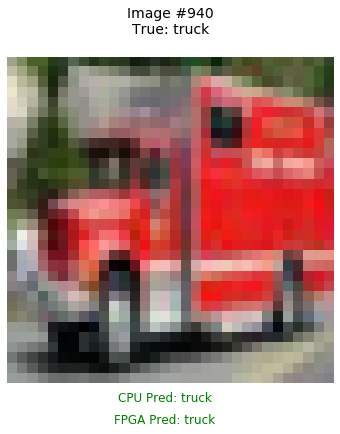

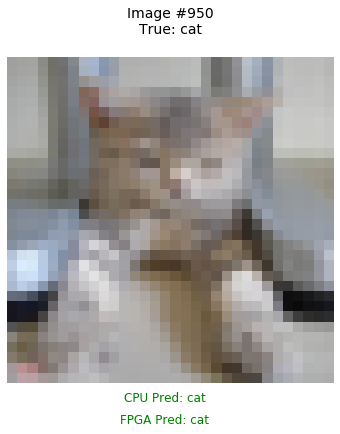

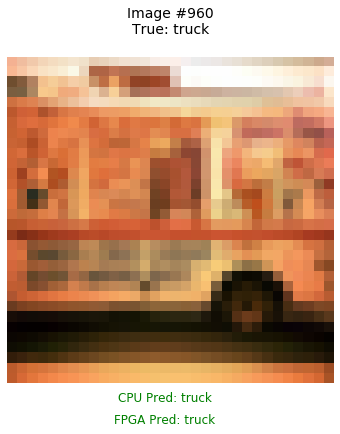

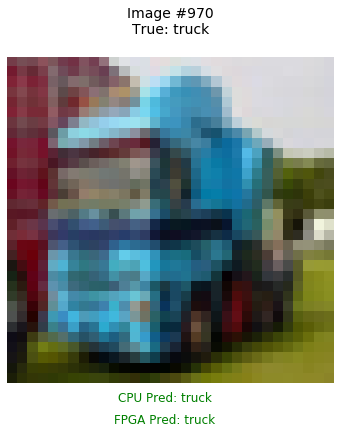

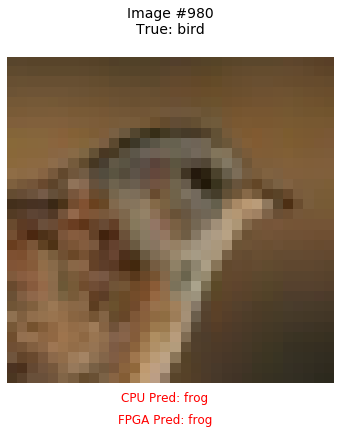

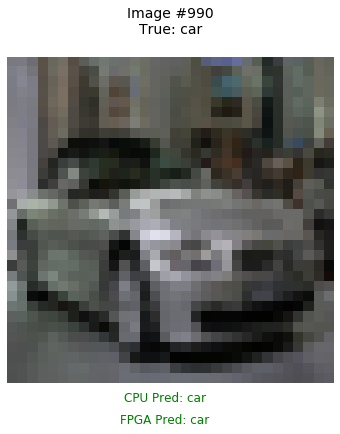

In [70]:

RUN_CPU_BENCHMARK = 1

# 버퍼를 루프 밖에서 한 번만 할당
print(f"\n[추론 준비] 공용 DMA 버퍼 할당 시도...")
try:
    MAX_IMAGE_ELEMS = 256 * 32 * 32  
    MAX_FILTER_ELEMS = 590080        
    MAX_OUTPUT_ELEMS = 32 * 32 * 256 
    
    image_buffer_shared = allocate(shape=(MAX_IMAGE_ELEMS,), dtype=DTYPE_IN)
    filter_buffer_shared = allocate(shape=(MAX_FILTER_ELEMS,), dtype=DTYPE_IN_BIAS)
    output_buffer_shared = allocate(shape=(MAX_OUTPUT_ELEMS,), dtype=DTYPE_OUT)
    print("공용 DMA 버퍼 3개 할당 성공.")
except Exception as e:
    print(f"치명적 오류: 공용 DMA 버퍼 할당 실패: {e}")
    print("PYNQ 보드를 재부팅하거나, CMA 메모리가 충분한지 확인하세요.")
    # exit()


NUM_TEST_IMAGES = 1000
print(f"\n테스트셋 *{NUM_TEST_IMAGES}*개 이미지에 대한 정확도 비교 시작...")
if RUN_CPU_BENCHMARK == 0:
    print("  (참고: CPU 벤치마크 [A]가 비활성화되었습니다.)")

correct_a = 0 # [A] PyTorch CPU 추론 카운터
correct_b = 0 # [B] PYNQ FPGA 가속 추론 카운터
total = 0
total_time_a_ms = 0.0 # [성능 비교] 총 CPU 시간
total_time_b_ms = 0.0 # [성능 비교] 총 FPGA 시간


try:
    with torch.no_grad():
        for i, (images, labels) in enumerate(test_loader):
            
            if i >= NUM_TEST_IMAGES:
                print(f"{NUM_TEST_IMAGES}개 이미지 테스트 완료. 루프 종료.")
                break
                
            images, labels = images.to(device), labels.to(device)
            
            time_a_ms = 0.0
            pred_a = None # 플롯 함수가 None을 처리할 수 있도록 함
            
            # (A) 기준점: 순수 PyTorch(CPU)로만 추론
            if RUN_CPU_BENCHMARK == 1:
                start_a = time.time()
                output_a = inference_model(images)
                end_a = time.time()
                _, pred_a = torch.max(output_a.data, 1)
                time_a_ms = (end_a - start_a) * 1000
                total_time_a_ms += time_a_ms
                correct_a += (pred_a == labels).sum().item()

            # (B) 검증 대상: PYNQ FPGA 가속 추론
            start_b = time.time()
            output_b = pynq_accelerated_inference(inference_model, images,
                                                image_buffer_shared,
                                                filter_buffer_shared,
                                                output_buffer_shared,
                                                layer_params_list,
                                                prequantized_data_list)
            end_b = time.time()
            
            # [수정] output_b가 None일 경우(추론 실패) 처리
            if output_b is None:
                print(f"  (B) PYNQ 추론 실패 (이미지 #{i}). 테스트 중단.")
                break
                
            _, pred_b = torch.max(output_b.data, 1) # [오타 수정 완료]

            # 카운트 업데이트
            total += labels.size(0)
            # correct_a는 (A) 블록 내부에서만 업데이트
            correct_b += (pred_b == labels).sum().item() # [오타 수정 완료]

            # 시간 측정 및 출력
            time_b_ms = (end_b - start_b) * 1000
            total_time_b_ms += time_b_ms
            
            if RUN_CPU_BENCHMARK == 1:
                print(f"[이미지 #{i}] Time (CPU): {time_a_ms:8.2f} ms | Time (FPGA): {time_b_ms:8.2f} ms")
            else:
                print(f"[이미지 #{i}] Time (FPGA): {time_b_ms:8.2f} ms")
            # 종료

            # 10의 배수 이미지 플롯
            if i % 10 == 0:
                pred_a_val = pred_a.item() if pred_a is not None else None
                plot_inference_result(images[0], 
                                      pred_a_val, 
                                      pred_b.item(), 
                                      labels.item(), 
                                      i)
            # 종료

finally:
    print("\n공용 DMA 버퍼 해제 중...")
    image_buffer_shared.freebuffer()
    filter_buffer_shared.freebuffer()
    output_buffer_shared.freebuffer()
    del image_buffer_shared
    del filter_buffer_shared
    del output_buffer_shared
    print("공용 DMA 버퍼 모두 해제됨.")


# 최종 최종 정확도 계산
# [수정] total이 0일 경우 ZeroDivisionError 방지
if total > 0:
    accuracy_a = 100 * correct_a / total
    accuracy_b = 100 * correct_b / total
    avg_time_a_ms = total_time_a_ms / total if RUN_CPU_BENCHMARK == 1 else 0.0
    avg_time_b_ms = total_time_b_ms / total
else:
    accuracy_a = 0.0
    accuracy_b = 0.0
    avg_time_a_ms = 0.0
    avg_time_b_ms = 0.0

print("\n" + "=" * 50)
print(f"     *PYNQ 테스트* 최종 정확도 비교 결과 ({total}개 샘플)")
print("=" * 50)
# [신규] CPU 스위치 상태에 따라 조건부 출력
if RUN_CPU_BENCHMARK == 1:
    print(f"  - [A] PyTorch CPU 추론 정확도: \t{accuracy_a:.2f} % ({correct_a}/{total})")
print(f"  - [B] PYNQ FPGA 가속 추론 정확도: \t{accuracy_b:.2f} % ({correct_b}/{total})")
if RUN_CPU_BENCHMARK == 1:
    print("-" * 50)
    print(f"  - 정확도 차이 (A - B): {accuracy_a - accuracy_b:+.2f} %")

print("\n" + "=" * 50)
print(f"     *PYNQ 테스트* 최종 성능 비교 결과 ({total}개 샘플)")
print("=" * 50)
if RUN_CPU_BENCHMARK == 1:
    print(f"  - [A] CPU 평균 추론 시간: \t{avg_time_a_ms:.2f} ms/image")
print(f"  - [B] FPGA 평균 추론 시간: \t{avg_time_b_ms:.2f} ms/image")
print("-" * 50)
if RUN_CPU_BENCHMARK == 1 and avg_time_a_ms > 0:
    speedup = avg_time_a_ms / avg_time_b_ms
    print(f"  - FPGA 가속 성능: {speedup:.2f}x (CPU 대비)")
else:
    print("  - FPGA 가속 성능: (CPU 벤치마크 Off)")

print("\nPYNQ 추론 스크립트 종료.")

